<a href="https://colab.research.google.com/github/mushrifahamed/DL-Assignment1/blob/model_DenseNet/03_densenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DenseNet Brain Tumor Classification

**Model 4: DenseNet (Dense Convolutional Network)**

This notebook implements DenseNet for multi-class brain tumor classification from MRI images.

**Dataset**: Brain tumor MRI dataset from Kaggle (7,023 images)
**Classes**: glioma, meningioma, no tumor, pituitary
**Architecture**: DenseNet121 with transfer learning


## Download Dataset


In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip -d /content/brain_tumor_dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
 85% 127M/149M [00:00<00:00, 1.32GB/s]
100% 149M/149M [00:00<00:00, 1.13GB/s]


In [5]:
import kagglehub

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


## Environment Setup


In [4]:
!nvidia-smi
!python --version

import os, random, numpy as np, tensorflow as tf
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = "/content/drive/MyDrive/DL-Assignment/brain_tumor_dataset"


Fri Oct 10 17:19:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Dataset Loader


In [6]:
import os, tensorflow as tf
if os.path.exists("densenet_phase1.keras"):
    model = tf.keras.models.load_model("densenet_phase1.keras")
from tensorflow.keras import layers
from tensorflow.keras.applications.densenet import preprocess_input

# ===== paths =====
# The path printed by kagglehub.dataset_download
DATA_ROOT = "/kaggle/input/brain-tumor-mri-dataset"
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR  = os.path.join(DATA_ROOT, "Testing")

# ===== settings (keep same across all 4 models) =====
IMG_SIZE  = 224          # DenseNet input size
BATCH     = 32
SEED      = 42
AUTOTUNE  = tf.data.AUTOTUNE
VAL_SPLIT = 0.15         # 15% of Training used as validation

# ===== create train/val directly from Training/ (stratified per class) =====
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",         # one-hot for 4 classes
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset="training",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    shuffle=False,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
)

# ===== test from Testing/ (no split, no shuffle) =====
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    shuffle=False,
)

class_names = train_ds.class_names
print("Class order:", class_names)    # e.g. ['glioma','meningioma','notumor','pituitary']

Found 5712 files belonging to 4 classes.
Using 4856 files for training.
Found 5712 files belonging to 4 classes.
Using 856 files for validation.
Found 1311 files belonging to 4 classes.
Class order: ['glioma', 'meningioma', 'notumor', 'pituitary']


## Pipelines (augmentation + DenseNet preprocess)


In [7]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
from tensorflow.keras import layers
from tensorflow.keras.applications.densenet import preprocess_input

IMG_SIZE = 224
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

# If you already created train_ds/val_ds/test_ds, reuse them; otherwise run the creation cell again.
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augment")

def densenet_preprocess(x, y):
    return preprocess_input(x), y     # required for DenseNet weights

# ===== final pipelines (fast) =====
def prep_train(ds):
    return (ds
            .map(lambda x,y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .map(densenet_preprocess, num_parallel_calls=AUTOTUNE)
            .cache().prefetch(AUTOTUNE))

def prep_eval(ds):
    return (ds
            .map(densenet_preprocess, num_parallel_calls=AUTOTUNE)
            .cache().prefetch(AUTOTUNE))

train_pp = prep_train(train_ds)
val_pp   = prep_eval(val_ds)
test_pp  = prep_eval(test_ds)


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Class distribution & class weights (helps with imbalance)


In [8]:
import numpy as np, collections

# Count per-class from the TRAIN split
ys = np.concatenate([y.numpy() for _, y in train_ds.unbatch().batch(10000)])
counts = ys.sum(axis=0)
total = counts.sum()
class_weights = {i: float(total/(len(counts)*counts[i])) for i in range(len(counts))}

print("Class names:", class_names)
print("Train counts:", dict(zip(class_names, counts.astype(int))))
print("Class weights:", class_weights)


Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train counts: {'glioma': np.int64(1142), 'meningioma': np.int64(1154), 'notumor': np.int64(1336), 'pituitary': np.int64(1224)}
Class weights: {0: 1.0630472898483276, 1: 1.0519930124282837, 2: 0.908682644367218, 3: 0.991830050945282}


## Build DenseNet Transfer Model


In [9]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
from tensorflow.keras import layers, models, optimizers, callbacks

# Load DenseNet121 base model
base = DenseNet121(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False  # Phase 1: freeze

inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))
# (We already augment & preprocess in the pipeline)
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation="softmax", dtype="float32")(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)
model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

## Callbacks


In [10]:
cbs = [
  callbacks.ModelCheckpoint("densenet_best.h5", monitor="val_accuracy", save_best_only=True),
  callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
  callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
]


## Train — Phase 1 (frozen base)


In [11]:
hist1 = model.fit(
    train_pp,
    epochs=15,
    validation_data=val_pp,
    class_weight=class_weights,   # optional but recommended if counts are imbalanced
    callbacks=cbs
)

model.save("densenet_phase1.keras")


Epoch 1/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.5821 - loss: 1.1123 - precision: 0.6413 - recall: 0.5107

152/152 ━━━━━━━━━━━━━━━━━━━━ 126s 603ms/step - accuracy: 0.5829 - loss: 1.1101 - precision: 0.6421 - recall: 0.5115 - val_accuracy: 0.9825 - val_loss: 0.1695 - val_precision: 0.9916 - val_recall: 0.9685 - learning_rate: 0.0010
Epoch 2/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.8092 - loss: 0.5069 - precision: 0.8376 - recall: 0.7779 - val_accuracy: 0.9778 - val_loss: 0.1460 - val_precision: 0.9881 - val_recall: 0.9661 - learning_rate: 0.0010
Epoch 3/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.8298 - loss: 0.4482 - precision: 0.8496 - recall: 0.8012 - val_accuracy: 0.9766 - val_loss: 0.1321 - val_precision: 0.9870 - val_recall: 0.9720 - learning_rate: 0.0010
Epoch 4/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8401 - loss: 0.4244 - precision: 0.8621 - recall: 0.8110 - val_accuracy: 0.9743 - val_loss: 0.1572 - val_precision: 0.9822 - val_recall: 0.9685 - learning_rate: 0.0010
Epoch 5/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8

152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.8604 - loss: 0.3729 - precision: 0.8755 - recall: 0.8382 - val_accuracy: 0.9836 - val_loss: 0.0993 - val_precision: 0.9859 - val_recall: 0.9790 - learning_rate: 0.0010
Epoch 7/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8636 - loss: 0.3564 - precision: 0.8775 - recall: 0.8446 - val_accuracy: 0.9801 - val_loss: 0.1138 - val_precision: 0.9846 - val_recall: 0.9731 - learning_rate: 0.0010
Epoch 8/15
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8637 - loss: 0.3552 - precision: 0.8817 - recall: 0.8471

152/152 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.8637 - loss: 0.3552 - precision: 0.8816 - recall: 0.8471 - val_accuracy: 0.9942 - val_loss: 0.0566 - val_precision: 0.9965 - val_recall: 0.9918 - learning_rate: 0.0010
Epoch 9/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.8677 - loss: 0.3469 - precision: 0.8863 - recall: 0.8499 - val_accuracy: 0.9930 - val_loss: 0.0431 - val_precision: 0.9941 - val_recall: 0.9895 - learning_rate: 0.0010
Epoch 10/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.8673 - loss: 0.3503 - precision: 0.8774 - recall: 0.8516 - val_accuracy: 0.9661 - val_loss: 0.1567 - val_precision: 0.9728 - val_recall: 0.9614 - learning_rate: 0.0010
Epoch 11/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8701 - loss: 0.3391 - precision: 0.8810 - recall: 0.8581 - val_accuracy: 0.9650 - val_loss: 0.1545 - val_precision: 0.9705 - val_recall: 0.9614 - learning_rate: 0.0010
Epoch 12/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.

## Fine-tune — Phase 2 (unfreeze last DenseNet blocks, small LR)


In [12]:
# Unfreeze top ~2 blocks (~24 conv layers) — adjust if you see overfitting
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-24:]:
    layer.trainable = True

model.compile(
    optimizer=optimizers.Adam(5e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

hist2 = model.fit(
    train_pp,
    epochs=10,
    validation_data=val_pp,
    class_weight=class_weights,
    callbacks=cbs
)


Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 86s 320ms/step - accuracy: 0.8422 - loss: 0.4426 - precision: 0.8547 - recall: 0.8262 - val_accuracy: 0.9848 - val_loss: 0.0632 - val_precision: 0.9859 - val_recall: 0.9825 - learning_rate: 5.0000e-05
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.8876 - loss: 0.3025 - precision: 0.8982 - recall: 0.8714 - val_accuracy: 0.9836 - val_loss: 0.0725 - val_precision: 0.9871 - val_recall: 0.9813 - learning_rate: 5.0000e-05
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8971 - loss: 0.2654 - precision: 0.9070 - recall: 0.8888 - val_accuracy: 0.9860 - val_loss: 0.0585 - val_precision: 0.9883 - val_recall: 0.9860 - learning_rate: 5.0000e-05
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9125 - loss: 0.2339 - precision: 0.9227 - recall: 0.9030 - val_accuracy: 0.9871 - val_loss: 0.0559 - val_precision: 0.9871 - val_recall: 0.9871 - learning_rate: 5.0000e-05
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s

## Evaluate on test set + confusion matrix & report


41/41 ━━━━━━━━━━━━━━━━━━━━ 22s 532ms/step - accuracy: 0.8887 - loss: 0.2938 - precision: 0.8976 - recall: 0.8873
Test metrics: {'accuracy': 0.9122806787490845, 'loss': 0.239334374666214, 'precision': 0.9184615612030029, 'recall': 0.9107551574707031}
41/41 ━━━━━━━━━━━━━━━━━━━━ 24s 316ms/step
              precision    recall  f1-score   support

      glioma       0.91      0.89      0.90       300
  meningioma       0.87      0.79      0.83       306
     notumor       0.96      0.96      0.96       405
   pituitary       0.89      0.99      0.94       300

    accuracy                           0.91      1311
   macro avg       0.91      0.91      0.91      1311
weighted avg       0.91      0.91      0.91      1311



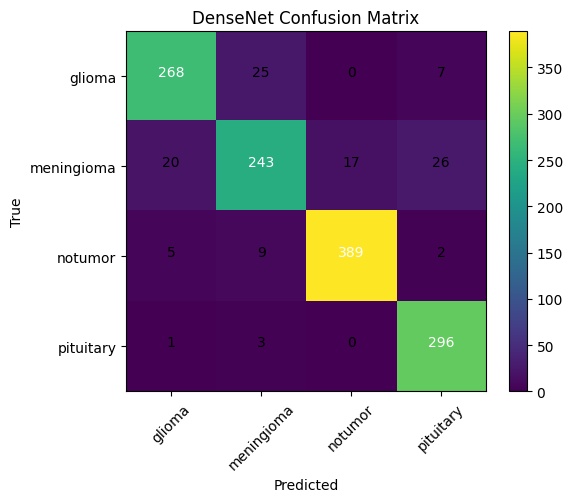

Macro ROC-AUC: 0.989898701490765


In [13]:
import numpy as np, itertools, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# Evaluate
test_metrics = model.evaluate(test_pp, return_dict=True)
print("Test metrics:", test_metrics)

# Predictions
y_prob = model.predict(test_pp)
y_true = np.argmax(np.vstack([y.numpy() for _, y in test_ds.unbatch().batch(10000)]), axis=1)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest'); plt.title("DenseNet Confusion Matrix"); plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=45); plt.yticks(ticks, class_names)
th = cm.max()/2.
for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i,j], ha="center", color="white" if cm[i,j] > th else "black")
plt.ylabel('True'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()

# Macro ROC-AUC (one-vs-rest) – optional but nice
y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
macro_auc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
print("Macro ROC-AUC:", macro_auc)


## Test one image from test dataset


1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step
Class order: ['glioma', 'meningioma', 'notumor', 'pituitary']
Predicted: glioma | True: glioma
Probabilities: {'glioma': 0.998, 'meningioma': 0.002, 'notumor': 0.0, 'pituitary': 0.0}


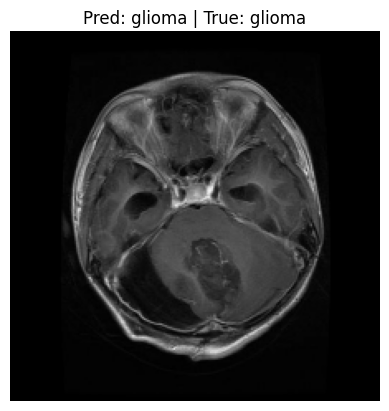

In [14]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras.applications.densenet import preprocess_input

IMG_SIZE = 224  # keep same as training

# (Optional) load best weights if you saved them
import os
if os.path.exists("densenet_best.h5"):
    model.load_weights("densenet_best.h5")

# take exactly one image from the test set
for img, label in test_ds.unbatch().take(1):
    # keep a copy for plotting
    vis = tf.cast(img, tf.uint8).numpy()

    # resize + preprocess for DenseNet
    x = tf.image.resize(img[None, ...], (IMG_SIZE, IMG_SIZE))
    x = tf.cast(x, tf.float32)
    x = preprocess_input(x)

    # predict
    probs = model.predict(x)
    pred_idx = int(np.argmax(probs[0]))
    true_idx = int(tf.argmax(label).numpy())

    # pretty print
    print("Class order:", class_names)
    print("Predicted:", class_names[pred_idx], "| True:", class_names[true_idx])
    print("Probabilities:", {c: float(f"{p:.3f}") for c, p in zip(class_names, probs[0])})

    # visualize
    plt.imshow(vis); plt.axis("off")
    plt.title(f"Pred: {class_names[pred_idx]} | True: {class_names[true_idx]}")
    plt.show()
    break


## Test one mini-batch


In [15]:
import numpy as np

# If you built test_pp (already preprocessed), use test_pp; else use test_ds with manual preprocess
use_preprocessed = True  # set to False if you didn't build test_pp

if use_preprocessed:
    for xb, yb in test_pp.take(1):
        probs = model.predict(xb)
        preds = probs.argmax(axis=1)
        trues = yb.numpy().argmax(axis=1)
        acc = (preds == trues).mean()
        print("Mini-batch accuracy:", acc)
        print("Pred →", [class_names[i] for i in preds[:8]])
        print("True →", [class_names[i] for i in trues[:8]])
        break
else:
    from tensorflow.keras.applications.densenet import preprocess_input
    # manually preprocess this batch
    for xb, yb in test_ds.take(1):
        xb = tf.image.resize(xb, (IMG_SIZE, IMG_SIZE))
        xb = preprocess_input(tf.cast(xb, tf.float32))
        probs = model.predict(xb)
        preds = probs.argmax(axis=1)
        trues = yb.numpy().argmax(axis=1)
        acc = (preds == trues).mean()
        print("Mini-batch accuracy:", acc)
        print("Pred →", [class_names[i] for i in preds[:8]])
        print("True →", [class_names[i] for i in trues[:8]])
        break


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Mini-batch accuracy: 0.96875
Pred → ['glioma', 'glioma', 'glioma', 'glioma', 'glioma', 'meningioma', 'glioma', 'glioma']
True → ['glioma', 'glioma', 'glioma', 'glioma', 'glioma', 'glioma', 'glioma', 'glioma']


## Test from a file path


In [16]:
import numpy as np, tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.densenet import preprocess_input

def predict_file(path):
    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x.astype("float32"))
    probs = model.predict(x)
    pred_idx = int(np.argmax(probs[0]))
    return class_names[pred_idx], {c: float(f"{p:.3f}") for c, p in zip(class_names, probs[0])}

pred, prob_dict = predict_file("/content/brain_tumor_dataset/Testing/glioma/Te-gl_0033.jpg")  # change path
print("Predicted:", pred)
print("Probabilities:", prob_dict)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted: glioma
Probabilities: {'glioma': 1.0, 'meningioma': 0.0, 'notumor': 0.0, 'pituitary': 0.0}


## Save the model


In [17]:
import json, os

SAVE_DIR = "/content/drive/MyDrive/DL-Assignment/densenet"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1) Save the full model (includes architecture + weights)
model.save(f"{SAVE_DIR}/densenet_phase2.keras")   # after fine-tuning

# 2) Save class names so label order stays consistent
with open(f"{SAVE_DIR}/class_names.json", "w") as f:
    json.dump(class_names, f)

# (Optional) Keep a checkpoint too (you already used ModelCheckpoint)
# It's handy if you ever want to reload just weights:
# model.save_weights(f"{SAVE_DIR}/densenet_best.weights.h5")


## Additional Testing Function


In [18]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np


def predict_file(path):
    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    x = img_to_array(img)[None, ...].astype("float32")
    x = preprocess_input(x)
    probs = model.predict(x)[0]
    pred = class_names[int(np.argmax(probs))]
    return pred, {c: float(f"{p:.3f}") for c, p in zip(class_names, probs)}

pred, prob = predict_file(f"{TEST_DIR}/meningioma/Te-me_0019.jpg")  # change file
print("Predicted:", pred)
print("Probs:", prob)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted: meningioma
Probs: {'glioma': 0.017, 'meningioma': 0.589, 'notumor': 0.092, 'pituitary': 0.302}


## Use saved Model


In [21]:
# 0) Mount Drive
# from google.colab import drive
# drive.mount('/content/drive')

# 1) Load saved model + class names
import json, tensorflow as tf
from tensorflow.keras.models import load_model

SAVE_DIR  = "/content/drive/MyDrive/DL-Assignment/densenet"
model = load_model(f"{SAVE_DIR}/densenet_phase2.keras")

with open(f"{SAVE_DIR}/class_names.json") as f:
    class_names = json.load(f)

# 2) Build ONLY the test dataset
IMG_SIZE = 224
BATCH    = 32
# Update TEST_DIR to the correct path
TEST_DIR = "/kaggle/input/brain-tumor-mri-dataset/Testing"

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    label_mode="categorical",
    shuffle=False
)

# 3) Preprocess for DenseNet and evaluate
from tensorflow.keras.applications.densenet import preprocess_input
test_pp = (test_ds
           .map(lambda x,y: (preprocess_input(tf.cast(x, tf.float32)), y),
                num_parallel_calls=tf.data.AUTOTUNE)
           .prefetch(tf.data.AUTOTUNE))

metrics = model.evaluate(test_pp, return_dict=True)
print("Test metrics:", metrics)

Found 1311 files belonging to 4 classes.
41/41 ━━━━━━━━━━━━━━━━━━━━ 33s 260ms/step - accuracy: 0.7924 - loss: 0.4779 - precision: 0.8088 - recall: 0.7648
Test metrics: {'accuracy': 0.8390541672706604, 'loss': 0.38721105456352234, 'precision': 0.8577138185501099, 'recall': 0.8184592127799988}


## Training History Visualization


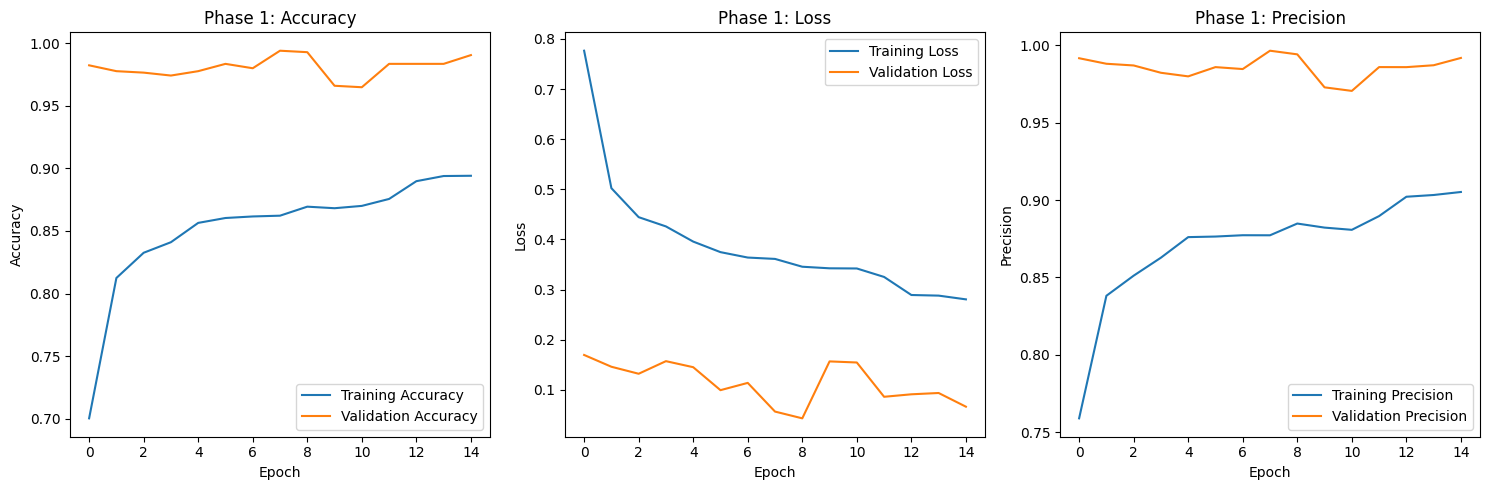

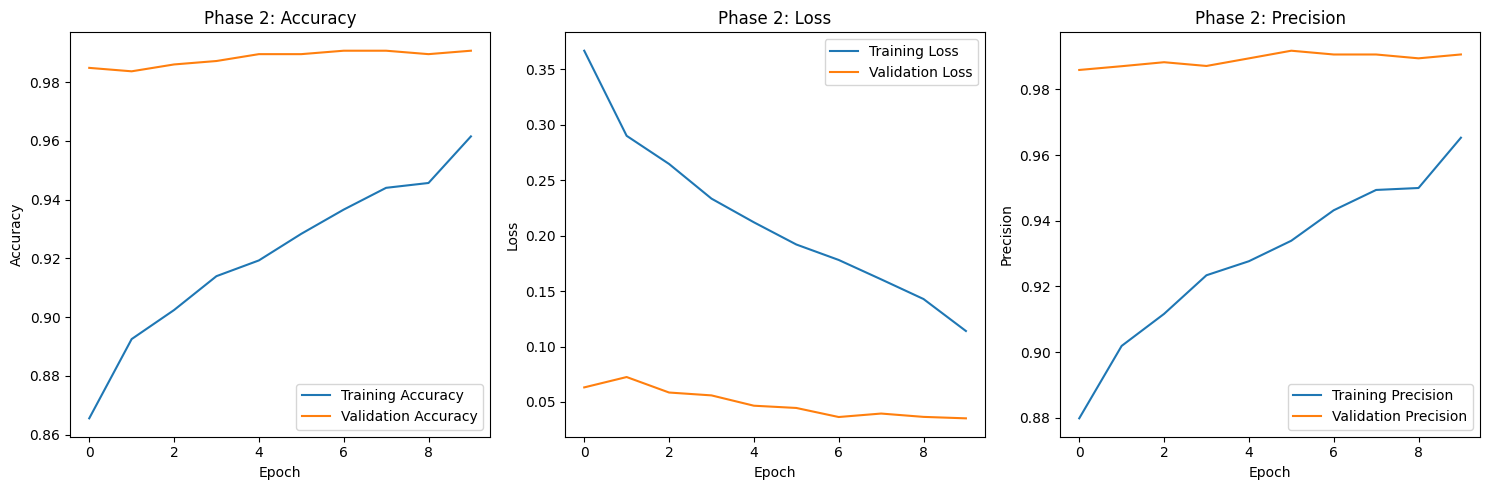

In [22]:
import matplotlib.pyplot as plt

# Plot training history for Phase 1
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(hist1.history['accuracy'], label='Training Accuracy')
plt.plot(hist1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Phase 1: Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(hist1.history['loss'], label='Training Loss')
plt.plot(hist1.history['val_loss'], label='Validation Loss')
plt.title('Phase 1: Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(hist1.history['precision'], label='Training Precision')
plt.plot(hist1.history['val_precision'], label='Validation Precision')
plt.title('Phase 1: Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()

plt.tight_layout()
plt.show()

# Plot training history for Phase 2
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(hist2.history['accuracy'], label='Training Accuracy')
plt.plot(hist2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Phase 2: Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(hist2.history['loss'], label='Training Loss')
plt.plot(hist2.history['val_loss'], label='Validation Loss')
plt.title('Phase 2: Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(hist2.history['precision'], label='Training Precision')
plt.plot(hist2.history['val_precision'], label='Validation Precision')
plt.title('Phase 2: Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()

plt.tight_layout()
plt.show()


## Model Architecture Summary


In [23]:
# Print model summary
print("DenseNet121 Model Summary:")
print("=" * 50)
model.summary()

# Count parameters
total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")

# DenseNet specific advantages
print("\nDenseNet Advantages for Medical Imaging:")
print("=" * 50)
print("1. Feature Reuse: Dense connections help with limited medical data")
print("2. Parameter Efficiency: Fewer parameters than VGG16")
print("3. Gradient Flow: Better gradient flow for deeper networks")
print("4. Feature Preservation: Maintains feature information through dense connections")


DenseNet121 Model Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,803,410 (33.58 MB)

 Trainable params: 751,236 (2.87 MB)

 Non-trainable params: 6,549,696 (24.99 MB)

 Optimizer params: 1,502,478 (5.73 MB)


Total parameters: 7,300,932
Trainable parameters: 751,236
Non-trainable parameters: 6,549,696

DenseNet Advantages for Medical Imaging:
1. Feature Reuse: Dense connections help with limited medical data
2. Parameter Efficiency: Fewer parameters than VGG16
3. Gradient Flow: Better gradient flow for deeper networks
4. Feature Preservation: Maintains feature information through dense connections
